# Imbalanced Data — Illustrated

When one class is rare (fraud, churn, defects) the model can score 99 % accuracy by predicting "not fraud" every time.
This notebook compares four standard fixes:

1. **Class weights** — penalise minority mistakes more.
2. **Random over-/under-sampling** — duplicate or drop rows.
3. **SMOTE** — synthesise new minority examples.
4. **Threshold tuning** — leave the model alone, move the cutoff.


## The picture — class ratio and four standard fixes

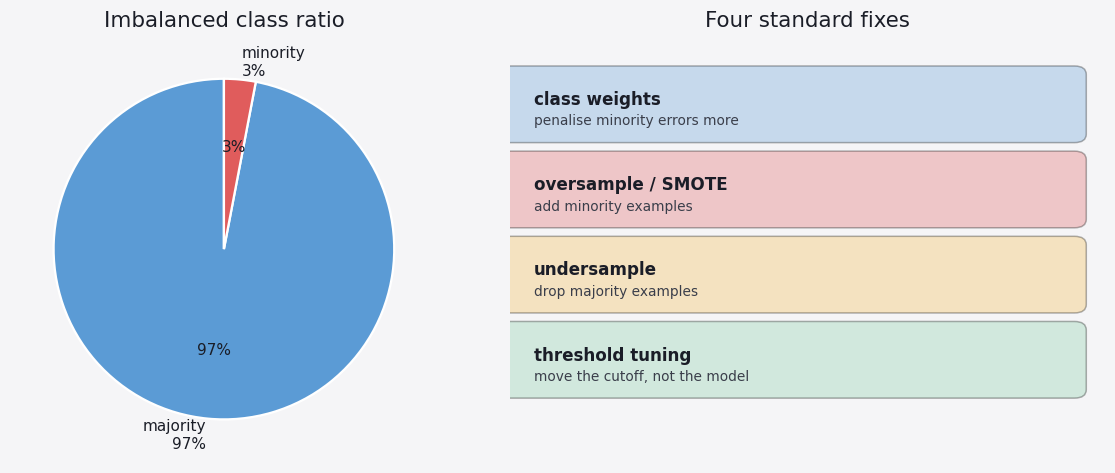

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ax = axes[0]
ax.pie([97, 3], labels=['majority\n97%','minority\n3%'],
       colors=[P[0], P[1]], autopct='%d%%', startangle=90,
       wedgeprops=dict(edgecolor='white', lw=1.5))
ax.set_title('Imbalanced class ratio')
ax = axes[1]; ax.axis('off')
fixes = [('class weights', 'penalise minority errors more'),
         ('oversample / SMOTE', 'add minority examples'),
         ('undersample', 'drop majority examples'),
         ('threshold tuning', 'move the cutoff, not the model')]
for i, (n, blurb) in enumerate(fixes):
    y = 0.85 - i*0.20
    ax.add_patch(FancyBboxPatch((0.0, y-0.08), 0.95, 0.14, boxstyle='round,pad=0.02',
                                facecolor=P[i % len(P)], alpha=0.30))
    ax.text(0.04, y, n, fontsize=11, weight='bold', va='center')
    ax.text(0.04, y-0.05, blurb, fontsize=9, va='center', color='#3a3e4a')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_title('Four standard fixes')
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_recall_curve, roc_curve,
                             precision_score, recall_score, f1_score, average_precision_score,
                             confusion_matrix)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

X, y = make_classification(n_samples=4000, n_features=10, n_informative=4,
                           weights=[0.97, 0.03], random_state=0, flip_y=0.02)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print(f'Train: {len(ytr)} rows, positive rate = {ytr.mean():.3f}')
print(f'Test : {len(yte)} rows, positive rate = {yte.mean():.3f}')


Train: 2800 rows, positive rate = 0.039
Test : 1200 rows, positive rate = 0.039


---
## Why accuracy lies — and PR vs ROC

A trivial classifier scores ~97 % accuracy. ROC stays flattering because TNR is huge.
the **precision-recall curve** is the honest one.


baseline:  acc=0.967  precision=1.00  recall=0.15  f1=0.26  AP=0.450


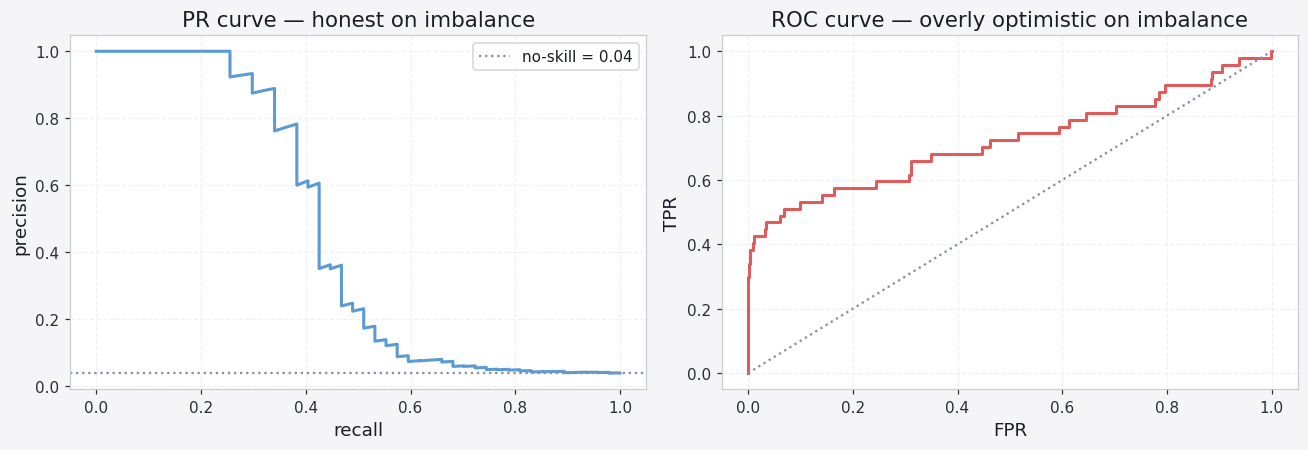

In [3]:
def fit_and_score(Xt, yt, Xv, yv, label):
    m = LogisticRegression(max_iter=2000).fit(Xt, yt)
    proba = m.predict_proba(Xv)[:, 1]
    pred  = (proba > 0.5).astype(int)
    return {'name': label,
            'acc':  (pred == yv).mean(),
            'precision': precision_score(yv, pred, zero_division=0),
            'recall':    recall_score(yv, pred),
            'f1':        f1_score(yv, pred),
            'ap':        average_precision_score(yv, proba),
            'proba': proba}

baseline = fit_and_score(Xtr, ytr, Xte, yte, 'baseline (no fix)')
print(f"baseline:  acc={baseline['acc']:.3f}  precision={baseline['precision']:.2f}  "
      f"recall={baseline['recall']:.2f}  f1={baseline['f1']:.2f}  AP={baseline['ap']:.3f}")

prec, rec, _ = precision_recall_curve(yte, baseline['proba'])
fpr, tpr, _  = roc_curve(yte, baseline['proba'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(rec, prec, color=PALETTE[0], lw=2)
axes[0].axhline(yte.mean(), color='#888fa5', ls=':', label=f'no-skill = {yte.mean():.2f}')
axes[0].set_xlabel('recall'); axes[0].set_ylabel('precision')
axes[0].set_title('PR curve — honest on imbalance'); axes[0].grid(True); axes[0].legend()

axes[1].plot(fpr, tpr, color=PALETTE[1], lw=2)
axes[1].plot([0,1],[0,1], color='#888fa5', ls=':')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC curve — overly optimistic on imbalance'); axes[1].grid(True)
plt.tight_layout(); plt.show()


---
## Four fixes head-to-head

Same model, same test set, four different training pipelines.


In [4]:
results = [baseline]

m = LogisticRegression(max_iter=2000, class_weight='balanced').fit(Xtr, ytr)
p = m.predict_proba(Xte)[:,1]
results.append({'name':'class_weight=balanced',
                'acc': ((p>0.5)==yte).mean(),
                'precision': precision_score(yte, p>0.5, zero_division=0),
                'recall': recall_score(yte, p>0.5), 'f1': f1_score(yte, p>0.5),
                'ap': average_precision_score(yte, p), 'proba': p})

for sampler, label in [(RandomOverSampler(random_state=0), 'random oversample'),
                       (RandomUnderSampler(random_state=0), 'random undersample'),
                       (SMOTE(random_state=0),              'SMOTE')]:
    Xs, ys = sampler.fit_resample(Xtr, ytr)
    results.append(fit_and_score(Xs, ys, Xte, yte, label))

import pandas as pd
df = pd.DataFrame([{k:v for k,v in r.items() if k!='proba'} for r in results])
print(df.round(3).to_string(index=False))


                 name   acc  precision  recall    f1    ap
    baseline (no fix) 0.967      1.000   0.149 0.259 0.450
class_weight=balanced 0.688      0.084   0.702 0.150 0.204
    random oversample 0.690      0.084   0.702 0.151 0.253
   random undersample 0.677      0.075   0.638 0.134 0.173
                SMOTE 0.682      0.085   0.723 0.151 0.152


---
## Threshold tuning

The cheapest fix of all: keep the model, move the decision cutoff so precision/recall match what the business wants.


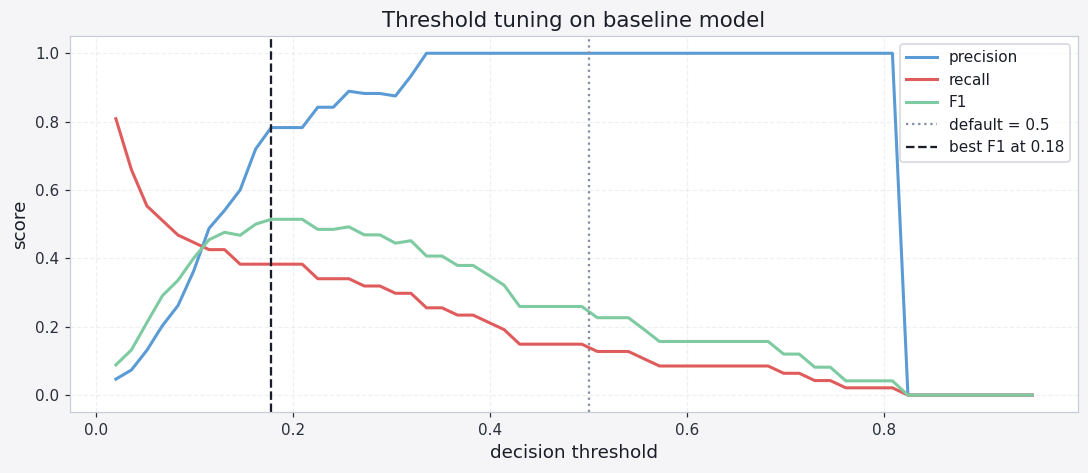

Default threshold F1 = 0.259
Tuned   threshold F1 = 0.514  at t = 0.18


In [5]:
proba = baseline['proba']
thresholds = np.linspace(0.02, 0.95, 60)
prec_list, rec_list, f1_list = [], [], []
for t in thresholds:
    pred = (proba > t).astype(int)
    prec_list.append(precision_score(yte, pred, zero_division=0))
    rec_list.append(recall_score(yte, pred))
    f1_list.append(f1_score(yte, pred))

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(thresholds, prec_list, color=PALETTE[0], lw=2, label='precision')
ax.plot(thresholds, rec_list,  color=PALETTE[1], lw=2, label='recall')
ax.plot(thresholds, f1_list,   color=PALETTE[3], lw=2, label='F1')
best = thresholds[int(np.argmax(f1_list))]
ax.axvline(0.5, color='#888fa5', ls=':', label='default = 0.5')
ax.axvline(best, color='#1a1d27', ls='--', label=f'best F1 at {best:.2f}')
ax.set_xlabel('decision threshold'); ax.set_ylabel('score')
ax.set_title('Threshold tuning on baseline model'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()
print(f'Default threshold F1 = {f1_score(yte, proba>0.5):.3f}')
print(f'Tuned   threshold F1 = {max(f1_list):.3f}  at t = {best:.2f}')


---
## When to use what

- **Class weights** — first thing to try; no data manipulation, no leakage risk.
- **Oversampling / SMOTE** — when classes are extremely rare and you can afford training cost.
- **Undersampling** — when the majority class is enormous and computation matters more than data.
- **Threshold tuning** — *always* do this last; the optimal cutoff is rarely 0.5.

> Pitfall: SMOTE/oversampling **before** train/test split is data leakage. Use a `Pipeline` from `imblearn.pipeline` so resampling happens only inside CV folds.
